In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


In [4]:
categories = [
    "sci.space",
    "comp.graphics",
    "rec.sport.baseball",
    "talk.politics.misc"
]

In [5]:
train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42
)

print("Categories:")
print(train_data.target_names)

print("\nTraining samples:", len(train_data.data))
print("Testing samples:", len(test_data.data))

Categories:
['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Training samples: 2239
Testing samples: 1490


In [6]:
print(train_data.data[0])

I thought that was Sandy Koufax.


In [7]:
vectorizer = CountVectorizer(
    stop_words="english",
    binary=True
)

X_train = vectorizer.fit_transform(
    train_data.data
)

X_test = vectorizer.transform(
    test_data.data
)

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape:", X_test.shape)

Training matrix shape: (2239, 26575)
Testing matrix shape: (1490, 26575)


In [9]:
model = BernoulliNB()

model.fit(
    X_train,
    train_data.target
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](4,)","[584.,597.,593.,465.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](4,)","[-1.34,-1.32,-1.33,-1.57]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](4,)","[0,1,2,3]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](4, 26575)","[[15., 8., 0.,..., 0., 2., 0.], [ 8.,15., 0.,..., 0., 0., 1.], [14.,27., 2.,..., 1., 0., 0.], [ 9.,19., 0.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](4, 26575)","[[-3.6 ,-4.18,-6.37,...,-6.37,-5.27,-6.37], [-4.2 ,-3.62,-6.4 ,...,-6.4 ,-6.4 ,-5.7 ], [-3.68,-3.06,-5.29,...,-5.7 ,-6.39,-6.39], [-3.84,-3.15,-6.15,...,-6.15,-6.15,-6.15]]"


In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(
    test_data.target,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6785234899328859


In [13]:
print(
    classification_report(
        test_data.target,
        y_pred,
        target_names=test_data.target_names
    )
)

                    precision    recall  f1-score   support

     comp.graphics       0.84      0.81      0.82       389
rec.sport.baseball       0.50      0.97      0.66       397
         sci.space       0.90      0.48      0.63       394
talk.politics.misc       0.87      0.40      0.55       310

          accuracy                           0.68      1490
         macro avg       0.78      0.66      0.66      1490
      weighted avg       0.77      0.68      0.67      1490



In [14]:
cm = confusion_matrix(
    test_data.target,
    y_pred
)

print(cm)

[[314  60  13   2]
 [  4 384   2   7]
 [ 48 147 189  10]
 [  7 173   6 124]]


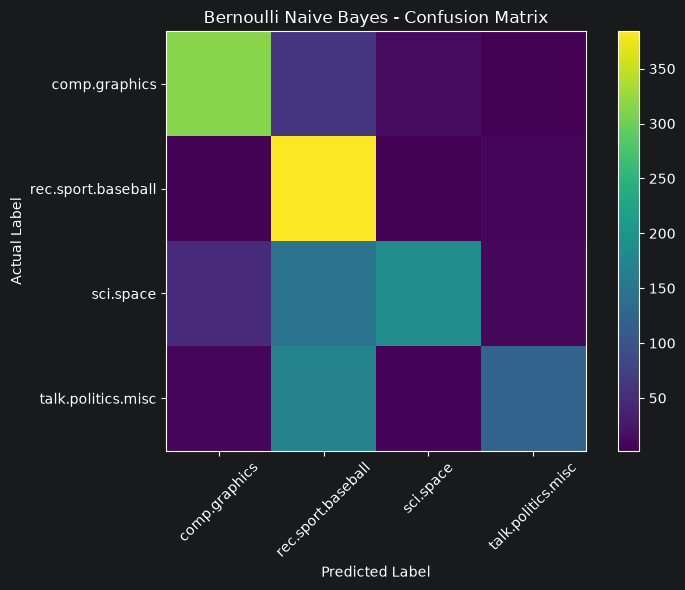

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(train_data.target_names)),
    train_data.target_names,
    rotation=45
)

plt.yticks(
    range(len(train_data.target_names)),
    train_data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Bernoulli Naive Bayes - Confusion Matrix")

plt.tight_layout()

plt.show()

In [16]:
my_text = [
    "NASA is planning a new spacecraft mission to explore space and planets"
]

my_text_vector = vectorizer.transform(
    my_text
)

prediction = model.predict(
    my_text_vector
)

predicted_category = train_data.target_names[
    prediction[0]
]

print("Predicted Category:", predicted_category)

Predicted Category: rec.sport.baseball


In [17]:
my_text = [
    "The baseball team won an exciting game and the player scored a home run"
]

my_text_vector = vectorizer.transform(
    my_text
)

prediction = model.predict(
    my_text_vector
)

print(
    "Predicted Category:",
    train_data.target_names[prediction[0]]
)

Predicted Category: rec.sport.baseball


In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

multinomial_model = MultinomialNB()

multinomial_model.fit(
    X_train,
    train_data.target
)

multi_pred = multinomial_model.predict(X_test)

multi_accuracy = accuracy_score(
    test_data.target,
    multi_pred
)

print("Multinomial Accuracy:", multi_accuracy)

Multinomial Accuracy: 0.8677852348993289


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    stop_words="english"
)

X_train_counts = count_vectorizer.fit_transform(
    train_data.data
)

X_test_counts = count_vectorizer.transform(
    test_data.data
)

In [20]:
multinomial_model = MultinomialNB()

multinomial_model.fit(
    X_train_counts,
    train_data.target
)

multi_pred = multinomial_model.predict(
    X_test_counts
)

multi_accuracy = accuracy_score(
    test_data.target,
    multi_pred
)

print("Multinomial Accuracy:", multi_accuracy)

Multinomial Accuracy: 0.8671140939597315


In [21]:
from sklearn.naive_bayes import BernoulliNB

binary_vectorizer = CountVectorizer(
    stop_words="english",
    binary=True
)

X_train_binary = binary_vectorizer.fit_transform(
    train_data.data
)

X_test_binary = binary_vectorizer.transform(
    test_data.data
)

bernoulli_model = BernoulliNB()

bernoulli_model.fit(
    X_train_binary,
    train_data.target
)

bernoulli_pred = bernoulli_model.predict(
    X_test_binary
)

bernoulli_accuracy = accuracy_score(
    test_data.target,
    bernoulli_pred
)

print("Bernoulli Accuracy:", bernoulli_accuracy)

Bernoulli Accuracy: 0.6785234899328859


In [22]:
print("\n--- FINAL COMPARISON ---")

print(
    f"Multinomial NB Accuracy: {multi_accuracy:.4f}"
)

print(
    f"Bernoulli NB Accuracy: {bernoulli_accuracy:.4f}"
)


--- FINAL COMPARISON ---
Multinomial NB Accuracy: 0.8671
Bernoulli NB Accuracy: 0.6785


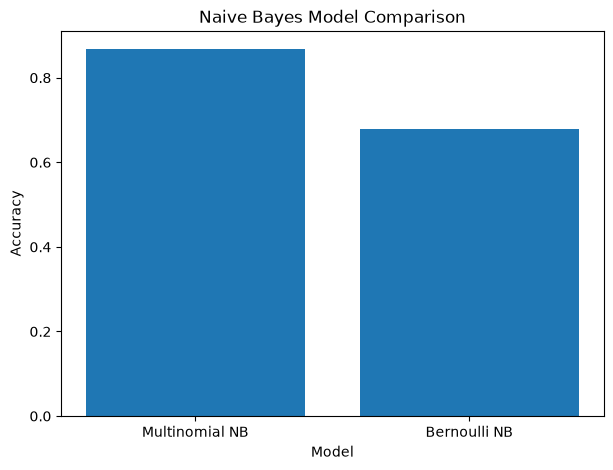

In [23]:
import matplotlib.pyplot as plt

models = [
    "Multinomial NB",
    "Bernoulli NB"
]

accuracies = [
    multi_accuracy,
    bernoulli_accuracy
]

plt.figure(figsize=(7, 5))

plt.bar(
    models,
    accuracies
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.title(
    "Naive Bayes Model Comparison"
)

plt.show()